# MDMP Structure Learning on Simulated DAGs

This notebook evaluates MDMP hill-climbing structure learning on two simulated DAG structures:
- 3-variable DAG (Figura 5): Y1 -> Y2 -> Y3 (chain)
- 5-variable DAG (Figura 6): Y1->Y2, Y1->Y3, Y2->Y4, Y3->Y4, Y2->Y5

We compute evaluation metrics including:
- Connection accuracy
- Sensitivity (true positive rate)
- Specificity (true negative rate)
- Positive Predictive Value (PPV)
- Negative Predictive Value (NPV)
- Directional accuracy

In [1]:
import os
import sys
import time
from itertools import combinations

import numpy as np
import pandas as pd

# Add parent directory to path to import mdmp
sys.path.insert(0, os.path.abspath('../..'))
from mdmp import MDM, plot_arcs

d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_connection_matrix(adj_mat):
    """Build symmetric connection matrix from directed adjacency matrix."""
    n_n = adj_mat.shape[0]
    k = np.zeros((n_n, n_n))

    # Get lower and upper triangle indices
    np.tril_indices(n_n, k=-1)
    np.triu_indices(n_n, k=1)

    # Get all pairwise combinations (same as R's combn)
    pairs = list(combinations(range(n_n), 2))
    lower_ind = [(i, j) for i, j in pairs if i > j]
    upper_ind = [(i, j) for i, j in pairs if i < j]

    # Build connection vector (undirected)
    m_con = np.zeros(len(pairs))
    for idx, (i, j) in enumerate(pairs):
        m_con[idx] = adj_mat[i, j] + adj_mat[j, i]

    # Build symmetric matrix
    for idx, (i, j) in enumerate(pairs):
        k[i, j] = k[j, i] = 1 if m_con[idx] == 1 else 0

    return {
        'connection_matrix': k,
        'connection_vector': m_con,
        'lower_ind': lower_ind,
        'upper_ind': upper_ind
    }


def compute_metrics(true_adj, estimated_adj):
    """Compute evaluation metrics for DAG structure learning."""
    n_n = true_adj.shape[0]

    # Build connection matrices (undirected representation)
    true_con = build_connection_matrix(true_adj)
    est_con = build_connection_matrix(estimated_adj)

    m_con_true = true_con['connection_vector']
    m_con_est = est_con['connection_vector']

    # Connection accuracy
    accuracy = np.mean(m_con_est == m_con_true)

    # Sensitivity (true positive rate)
    if np.any(m_con_true == 1):
        sensitivity = np.mean(m_con_est[m_con_true == 1] == 1)
    else:
        sensitivity = np.nan

    # Specificity (true negative rate)
    if np.any(m_con_true == 0):
        specificity = np.mean(m_con_est[m_con_true == 0] == 0)
    else:
        specificity = np.nan

    # Positive Predictive Value (PPV)
    if np.any(m_con_est == 1):
        ppv = np.mean(m_con_true[m_con_est == 1] == 1)
    else:
        ppv = np.nan

    # Negative Predictive Value (NPV)
    if np.any(m_con_est == 0):
        npv = np.mean(m_con_true[m_con_est == 0] == 0)
    else:
        npv = np.nan

    # Directional accuracy
    k = true_con['connection_matrix']
    true_con['upper_ind']
    true_con['lower_ind']

    # Get pairs where connections exist
    pairs_with_connections = [(i, j) for i, j in combinations(range(n_n), 2) if k[i, j] == 1]

    # Only evaluate directions where connections exist
    if pairs_with_connections:
        d_accuracy_vals = [
            (true_adj[i, j] == estimated_adj[i, j]) &
            (true_adj[j, i] == estimated_adj[j, i])
            for i, j in pairs_with_connections
        ]
        d_accuracy = np.mean(d_accuracy_vals)
    else:
        d_accuracy = np.nan

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'directional_accuracy': d_accuracy
    }

## Load Simulated Data

Load the simulated data files that were generated by `simulate_dags.py`.

In [3]:
# Define data directory
data_dir = "./data/"

# Load 3-variable data (Figura 5)
data_3var = pd.read_csv(os.path.join(data_dir, "dag_3var_simulated.csv"))
true_adj_3var = pd.read_csv(
    os.path.join(data_dir, "dag_3var_true_adjacency.csv"),
    index_col=0
).values.astype(int)

# Load 5-variable data (Figura 6)
data_5var = pd.read_csv(os.path.join(data_dir, "dag_5var_simulated.csv"))
true_adj_5var = pd.read_csv(
    os.path.join(data_dir, "dag_5var_true_adjacency.csv"),
    index_col=0
).values.astype(int)

print("3-variable data shape:", data_3var.shape)
print("3-variable true adjacency shape:", true_adj_3var.shape)
print("\n5-variable data shape:", data_5var.shape)
print("5-variable true adjacency shape:", true_adj_5var.shape)

3-variable data shape: (200, 3)
3-variable true adjacency shape: (3, 3)

5-variable data shape: (200, 5)
5-variable true adjacency shape: (5, 5)


## 3-Variable DAG: MDMP Structure Learning

In [4]:
# Run MDMP hill-climbing on 3-variable data
print("Running MDMP hill-climbing on 3-variable DAG...")
start_time = time.time()

model_3var = MDM(data_3var, method="hc", nbf=15, verbose=True)

end_time = time.time()
time_3var = end_time - start_time

print(f"\nTime taken: {time_3var:.2f} seconds")
print("\nEstimated adjacency matrix:")
print(pd.DataFrame(
    model_3var.adj_mat,
    index=model_3var.node_names,
    columns=model_3var.node_names
))

Running MDMP hill-climbing on 3-variable DAG...
Learning structure using method: hc


  0%|          | 2/1000000 [00:01<141:56:11,  1.96it/s]


Selecting discount factors...


Selecting discount factors: 100%|██████████| 153/153 [00:00<00:00, 155.58combinations/s]


Computing filtered estimates...


Filtering nodes: 100%|██████████| 3/3 [00:00<00:00, 154.23nodes/s]


Computing smoothed estimates...


Smoothing nodes: 100%|██████████| 3/3 [00:00<00:00, 111.02nodes/s]


MDM processing completed in 8.35 seconds

Time taken: 8.35 seconds

Estimated adjacency matrix:
    Y1  Y2  Y3
Y1   0   1   0
Y2   0   0   1
Y3   0   0   0


In [5]:
# Compute metrics for 3-variable DAG
metrics_3var = compute_metrics(true_adj_3var, model_3var.adj_mat)

print("Evaluation Metrics for 3-Variable DAG:")
print(f"  Accuracy: {metrics_3var['accuracy']:.4f}")
print(f"  Sensitivity: {metrics_3var['sensitivity']:.4f}")
print(f"  Specificity: {metrics_3var['specificity']:.4f}")
print(f"  PPV: {metrics_3var['ppv']:.4f}")
print(f"  NPV: {metrics_3var['npv']:.4f}")
print(f"  Directional Accuracy: {metrics_3var['directional_accuracy']:.4f}")

# Discount factors
print("\nDiscount Factors:")
for name, df_val in zip(model_3var.node_names, model_3var.DF['DF_hat']):
    print(f"  {name}: {df_val:.4f}")

# Number of edges
print(f"\nNumber of edges (estimated): {np.sum(model_3var.adj_mat)}")
print(f"Number of edges (true): {np.sum(true_adj_3var)}")

Evaluation Metrics for 3-Variable DAG:
  Accuracy: 1.0000
  Sensitivity: 1.0000
  Specificity: 1.0000
  PPV: 1.0000
  NPV: 1.0000
  Directional Accuracy: 1.0000

Discount Factors:
  Y1: 0.9600
  Y2: 0.9300
  Y3: 0.9300

Number of edges (estimated): 2
Number of edges (true): 2


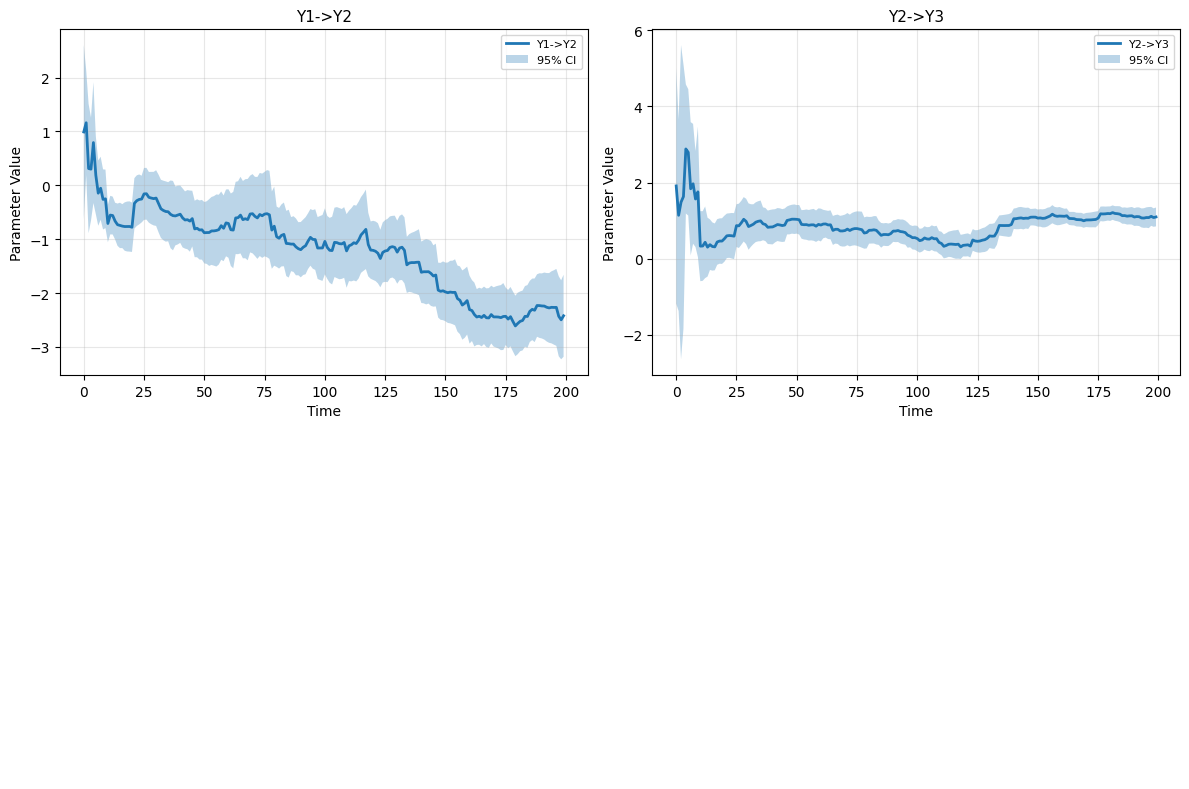

In [6]:
plot_arcs(model_3var, plot_type="connections", distribution="filt", ci_level=0.95);

## 5-Variable DAG: MDMP Structure Learning

In [7]:
# Run MDMP hill-climbing on 5-variable data
print("Running MDMP hill-climbing on 5-variable DAG...")
start_time = time.time()

model_5var = MDM(data_5var, method="hc", nbf=15, verbose=True, n_jobs=-1)

end_time = time.time()
time_5var = end_time - start_time

print(f"\nTime taken: {time_5var:.2f} seconds")
print("\nEstimated adjacency matrix:")
print(pd.DataFrame(
    model_5var.adj_mat,
    index=model_5var.node_names,
    columns=model_5var.node_names
))

Running MDMP hill-climbing on 5-variable DAG...
Learning structure using method: hc


  0%|          | 6/1000000 [00:03<181:51:23,  1.53it/s]


Selecting discount factors...


Selecting discount factors (parallel): 100%|██████████| 255/255 [00:04<00:00, 55.28combinations/s]


Computing filtered estimates...


Filtering nodes (parallel): 100%|██████████| 5/5 [00:02<00:00,  2.38nodes/s]


Computing smoothed estimates...


Smoothing nodes (parallel): 100%|██████████| 5/5 [00:02<00:00,  2.37nodes/s]



MDM processing completed in 15.34 seconds

Time taken: 15.34 seconds

Estimated adjacency matrix:
    Y1  Y2  Y3  Y4  Y5
Y1   0   1   1   0   0
Y2   0   0   1   1   1
Y3   0   0   0   1   0
Y4   0   0   0   0   0
Y5   0   0   0   0   0


In [8]:
# Compute metrics for 5-variable DAG
metrics_5var = compute_metrics(true_adj_5var, model_5var.adj_mat)

print("Evaluation Metrics for 5-Variable DAG:")
print(f"  Accuracy: {metrics_5var['accuracy']:.4f}")
print(f"  Sensitivity: {metrics_5var['sensitivity']:.4f}")
print(f"  Specificity: {metrics_5var['specificity']:.4f}")
print(f"  PPV: {metrics_5var['ppv']:.4f}")
print(f"  NPV: {metrics_5var['npv']:.4f}")
print(f"  Directional Accuracy: {metrics_5var['directional_accuracy']:.4f}")

# Discount factors
print("\nDiscount Factors:")
for name, df_val in zip(model_5var.node_names, model_5var.DF['DF_hat']):
    print(f"  {name}: {df_val:.4f}")

# Number of edges
print(f"\nNumber of edges (estimated): {np.sum(model_5var.adj_mat)}")
print(f"Number of edges (true): {np.sum(true_adj_5var)}")

Evaluation Metrics for 5-Variable DAG:
  Accuracy: 0.9000
  Sensitivity: 1.0000
  Specificity: 0.8000
  PPV: 0.8333
  NPV: 1.0000
  Directional Accuracy: 1.0000

Discount Factors:
  Y1: 1.0000
  Y2: 0.9500
  Y3: 0.9100
  Y4: 0.9000
  Y5: 0.8800

Number of edges (estimated): 6
Number of edges (true): 5


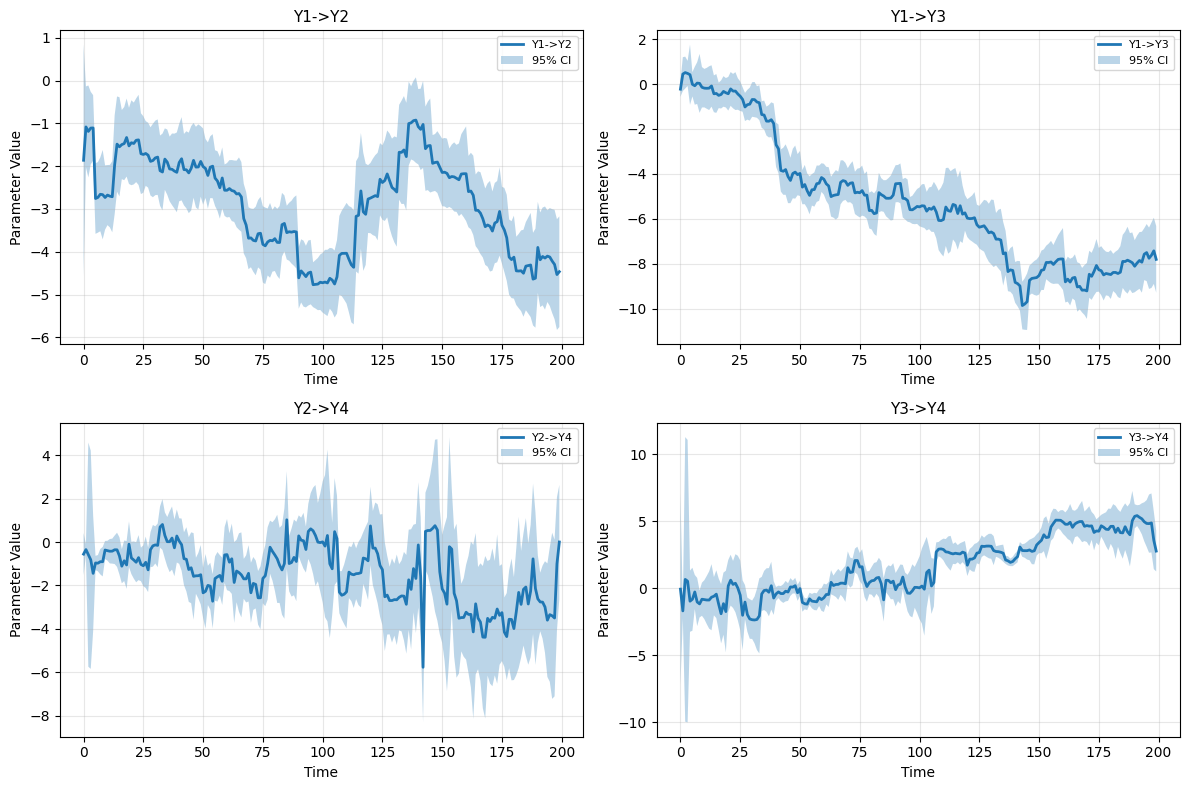

In [ ]:
plot_arcs(model_5var, plot_type="connections", distribution="filt", ci_level=0.95);

## Save Results

Save results to CSV files for comparison with MDMR results.

In [9]:
# Prepare results dataframes
results_3var = pd.DataFrame({
    'metric': ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'directional_accuracy',
               'num_edges_estimated', 'num_edges_true', 'computation_time'],
    'value': [
        metrics_3var['accuracy'],
        metrics_3var['sensitivity'],
        metrics_3var['specificity'],
        metrics_3var['ppv'],
        metrics_3var['npv'],
        metrics_3var['directional_accuracy'],
        np.sum(model_3var.adj_mat),
        np.sum(true_adj_3var),
        time_3var
    ]
})
results_3var['dag'] = '3var'
results_3var['method'] = 'mdmp'

results_5var = pd.DataFrame({
    'metric': ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'directional_accuracy',
               'num_edges_estimated', 'num_edges_true', 'computation_time'],
    'value': [
        metrics_5var['accuracy'],
        metrics_5var['sensitivity'],
        metrics_5var['specificity'],
        metrics_5var['ppv'],
        metrics_5var['npv'],
        metrics_5var['directional_accuracy'],
        np.sum(model_5var.adj_mat),
        np.sum(true_adj_5var),
        time_5var
    ]
})
results_5var['dag'] = '5var'
results_5var['method'] = 'mdmp'

# Combine and save
results_mdmp = pd.concat([results_3var, results_5var], ignore_index=True)
results_mdmp.to_csv(os.path.join(data_dir, "mdmp_results.csv"), index=False)

# Save adjacency matrices
pd.DataFrame(
    model_3var.adj_mat,
    index=model_3var.node_names,
    columns=model_3var.node_names
).to_csv(os.path.join(data_dir, "mdmp_adjacency_3var.csv"))

pd.DataFrame(
    model_5var.adj_mat,
    index=model_5var.node_names,
    columns=model_5var.node_names
).to_csv(os.path.join(data_dir, "mdmp_adjacency_5var.csv"))

print("Results saved to:", os.path.join(data_dir, "mdmp_results.csv"))

Results saved to: ./data/mdmp_results.csv
